In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
import pandas as pd
import astropy.units as u
from astropy import wcs
from astropy.io import fits
import astropy.coordinates as ac
from astropy.visualization import simple_norm, AsinhStretch, make_rgb, AsymmetricPercentileInterval
from skimage.draw import polygon, disk
from acstools import acszpt
from matplotlib import patches
import scipy.ndimage as nd
import gala.coordinates as gc
from scipy.interpolate import griddata
from skimage import measure


#import sys
#sys.path.append('scripts')
#from Conversion_functions import sum_mags, WFC_unit_conv, mag_to_cps
#from Image_mask_functions import get_mask_values, straighten_sausage


In [2]:
def WFC_unit_conv(image, filt, date ='2022-09-11', output='VEGAmag'):
    """
    Converts image values from cps to magnitudes using the HST conversion parameters.
    Since it uses active Query, this function needs internet connection to work. 

    Args
    - image is the image needed to be converted.
    - filt is filter name as string, eg 'F555W'. 
    - date is string in format 'yyyy-mm-dd'
    - output is the desired output units, either 'flux_density', or 'STmag', 'ABmag', or 'VEGAmag' for magnitudes.
        Flux density will be given in erg/s/cm^2/Angstrom.

    Returns
    - image with values in desired units.
    """
    q = acszpt.Query(date=date, detector='WFC', filt=filt)
    filter_zpt = q.fetch()
    if output == 'flux_density':
        F_lambda = image * u.electron/u.s * filter_zpt['PHOTFLAM']
        return F_lambda.value
    else:
        m = -2.5 * np.log10(image) + filter_zpt[output][0].value
        return m


In [3]:
def generate_perpendicular_offset(p1, p2, width):
    """
    Generate points that are perpendicular to the line segment defined by p1 and p2,
    offset by half the width on both sides.

    Args:
    - p1, p2: Points defining the line segment in (row, col) format.
    - width: Width of the "sausage"-shaped polygon.

    Returns:
    - Four points (row, col) representing the corners of the rectangle along the line segment.
    """
    # Vector along the line segment
    dx, dy = p2[1] - p1[1], p2[0] - p1[0]

    # Normalize the vector
    length = np.sqrt(dx**2 + dy**2)
    if length == 0:
        return [p1, p1, p2, p2]  # If p1 == p2, no offset is needed

    dx, dy = dx / length, dy / length

    # Perpendicular vector to (dx, dy)
    perp_dx, perp_dy = -dy, dx

    # Half the width on both sides
    offset = width / 2.0

    # Points offset by the perpendicular vector
    p1_offset1 = (p1[0] + perp_dy * offset, p1[1] + perp_dx * offset)
    p1_offset2 = (p1[0] - perp_dy * offset, p1[1] - perp_dx * offset)

    p2_offset1 = (p2[0] + perp_dy * offset, p2[1] + perp_dx * offset)
    p2_offset2 = (p2[0] - perp_dy * offset, p2[1] - perp_dx * offset)

    return [p1_offset1, p1_offset2, p2_offset1, p2_offset2]

def extract_sausage_shape(image, points, width, round_ends=True):
    """
    Extracts pixel values and coordinates inside a sausage-shaped polygon that follows
    a line of points with the specified width.

    Args:
    - image: A 2D NumPy array representing the image.
    - points: A NumPy array of shape (n, 2), where each row is a point (row, col) describing the line.
    - width: The width of the sausage-shaped polygon (diameter).

    Returns:
    - A tuple containing:
      - A list of pixel values inside the sausage-shaped polygon.
      - A list of coordinates (row, col) corresponding to these pixel values.
    """
    # Create a mask of the same shape as the image
    mask = np.zeros_like(image, dtype=bool)

    # Radius is half the width
    radius = width // 2
    
    # Draw a circular "sausage cap" at each point in the line. If you don't want rounded 
    # sausage ends, don't draw circles for the first few points in each end
    
    """This doesn't work yet
    few = int(radius/200 * len(points)) #assuming mask is ~200 pix long
    
    if not round_ends:
        chopped_points = points[few: -few]
        print(len(points), few, len(chopped_points))
    else:
        chopped_points = points
    """
    chopped_points = points
        
    for point in chopped_points:
        rr, cc = disk((point[0], point[1]), radius, shape=image.shape)
        mask[rr, cc] = True
    
    # Draw "rectangular" portions between each pair of consecutive points to connect them
    for i in range(len(points) - 1):
        p1, p2 = points[i], points[i + 1]

        # Generate the polygon coordinates for the rectangle that connects p1 and p2
        corners = generate_perpendicular_offset(p1, p2, width)

        # Get the integer row and col for the polygon mask
        poly_row = np.array([corners[0][0], corners[1][0], corners[3][0], corners[2][0]])
        poly_col = np.array([corners[0][1], corners[1][1], corners[3][1], corners[2][1]])
        rr, cc = polygon(poly_row, poly_col, shape=image.shape)
        mask[rr, cc] = True
    
    # Extract the pixel values and coordinates of the masked region
    sausage_values = image[mask]
    sausage_coords = np.column_stack(np.nonzero(mask))  # Get the coordinates in (row, col)

    return sausage_values, sausage_coords

def extract_circle_values_and_coords(image, center, radius):
    """
    Extracts both the pixel values and their coordinates inside a circle defined by a center and radius.
    
    Args:
    - image: A 2D NumPy array representing the image
    - center: A tuple (row, col) defining the center of the circle.
    - radius: The radius of the circle.
    
    Returns:
    - A tuple containing:
      - A list of pixel values inside the circle area.
      - A list of coordinates (row, col) corresponding to these pixel values.
    """
    # Get the coordinates of pixels inside the circular mask (disk)
    mask_row, mask_col = disk(center, radius, shape=image.shape)
    
    # Extract pixel values from the image using the circular mask
    circle_values = image[mask_row, mask_col]
    
    # Create a list of coordinates (row, col) inside the circle
    circle_coords = np.column_stack((mask_row, mask_col))  # Stack row and col into (row, col) coordinate pairs
    
    return circle_values, circle_coords

def extract_polygon_values(image, points):
    """
    Extracts the pixel values inside a polygon outlined by the given coordinates.
    
    Args:
    - image: A 2D NumPy array representing the image (shape: (5000, 6000)).
    - points: A NumPy array of shape (n, 2) containing the coordinates of the polygon vertices.
    
    Returns:
    - A list of pixel values inside the polygon area.
    """
    # Separate the points into x and y coordinates
    row = points[:, 0]  # y coordinates (rows)
    col = points[:, 1]  # x coordinates (columns)
    
    # Get the polygon mask (row, col are the coordinates of the pixels inside the polygon)
    mask_row, mask_col = polygon(row, col, image.shape)
    
    # Extract pixel values from the image using the mask
    polygon_values = image[mask_row, mask_col]
    
    # Create a list of coordinates (row, col) inside the polygon
    polygon_coords = np.column_stack((mask_row, mask_col))  # Stack row and col into (row, col) coordinate pairs
    
    return polygon_values, polygon_coords

def get_mask_values(name, image, shape='sausage', round_ends = True, width = 10, offset = (0,0), xlim=(2300, 2700), ylim=(3000,2600),
                    image_mask=None):
    """ 
    name is filename, either to be loaded or saved if drawnew=True
    image is the image getting the values from. Make sure the units align with the Magnitudes-arg, to ensure correct summation
    shape can be either 'polygon', 'circle', or 'sausage'
    if shape is sausage or circle, width is width or diameter
    offset (2d tuple or array as (y,x)), marks the  distance to the offstream mask. If None offstream will not be marked on the image_mask
    
    returns value for the area, as well as an identical area offset by an amount of pixels, 
    and image with the relevant masks applied. 
    """
    if type(name)==str:        
        try:
            df = pd.read_csv('../Clicked_points/'+name)
            points = df.to_numpy()
            
            #flip so the coordinates are (y,x) since indices are ordered (row,col)
            point_int = np.flip(points, axis=1).astype(int)
            
        except:
            print('No such file exists, draw new')
            return
    elif type(name)==np.ndarray:
        assert name.shape == (2,), 'Shape of input array should be (2,) containing circle center'
        point_int = np.flip(name, axis=0).astype(int)
    else:
        print('Input needs to be either filename str or coordinate array')
        return
    
    point_off = point_int
    
    if offset is not None:
        point_off = point_int+offset
    
    if shape=='sausage':
        val, coords = extract_sausage_shape(image, point_int, width=width, round_ends = round_ends)
        valoff, coordsoff = extract_sausage_shape(image, point_off, width=width, round_ends = round_ends)
    
    elif shape=='circle':
        if point_int.shape != (2,):
            point_int = point_int[0]
            point_off = point_off[0]
        cx, cy = point_int
        val, coords = extract_circle_values_and_coords(image, (cx, cy), width/2)
        cx, cy = point_off
        valoff, coordsoff = extract_circle_values_and_coords(image, (cx, cy), width/2)

    elif shape=='polygon':
        val, coords = extract_polygon_values(image, point_int)
        valoff, coordsoff = extract_polygon_values(image, point_off)
    
    else:
        print('shape does not exist')
        return
    
    if image_mask is not None:
        for i,j in (coords):
            image_mask[i,j] = image[i,j]
        if offset is not None:
            for i,j in (coordsoff):
                image_mask[i,j] = image[i,j]
    
    return val, valoff, coords, coordsoff

In [4]:
#  loading the two image files from ACS F555W and ACS F814W
filename555= '../Data_HST/hst_16890_03_acs_wfc_f555w_jesd03'
hdu_f555w = fits.open(filename555+'_drc.fits')
im555 = fits.getdata(filename555+'_drc.fits')

filename814= '../Data_HST/hst_16890_03_acs_wfc_f814w_jesd03'
hdu_f814w = fits.open(filename814+'_drc.fits')
im814 = fits.getdata(filename814+'_drc.fits')

wcs_HST = wcs.WCS(hdu_f555w[1].header)
px_size = (hdu_f555w[0].header['D001SCAL']*u.arcsec.to(u.rad)*35.2e6*u.pc).value # pixel size in arcsec
px_size


8.532720787527834

In [5]:
def background_correction(file, shape, width, offsets, plot=True):
    # Create masks for illustration
    masks = np.full(im555.shape, np.nan)
    streammask = np.full(im555.shape, np.nan)
    
    # Get values from stream area
    stream_555, _, stream_coords, _ = get_mask_values(file, image = im555, shape=shape, width = width, offset=None, image_mask=streammask)
    stream_814, *_ = get_mask_values(file, image = im814, shape=shape, width = width, offset=None, image_mask=None)
    err_555 = np.std(stream_555)*np.sqrt(len(stream_555)) #std is per pixel, so multiply by sqrtN
    err_814 = np.std(stream_814)*np.sqrt(len(stream_814))
    stream_mag555 = WFC_unit_conv(np.sum(stream_555), filt='F555W', output='VEGAmag')
    stream_mag814 = WFC_unit_conv(np.sum(stream_814), filt='F814W', output='VEGAmag')
    print(f'Stream cps F555W: {np.sum(stream_555):.4f} cps')
    print(f'Stream cps F814W: {np.sum(stream_814):.4f} cps')
    print(f'Stream error F555W: {err_555:.4f} cps')
    print(f'Stream error F814W: {err_814:.4f} cps')
    print(f'Stream F555W magnitude: {stream_mag555:.4f} mag')
    print(f'Stream F814W magnitude: {stream_mag814:.4f} mag')

    # Get background values for a range of offsets
    bright555 =[]
    bright814 =[]
    
    for o in offsets:
        _,off_555, *_ = get_mask_values(file, image = im555, shape=shape, width = width, offset=o, image_mask=masks)
        _,off_814, *_ = get_mask_values(file, image = im814, shape=shape, width = width, offset=o, image_mask=None)
        bright555.append(np.sum(off_555))
        bright814.append(np.sum(off_814))
    
    
    avg_bck555 = np.mean(bright555)
    avg_bck814 = np.mean(bright814)

    corr_stream555 = np.sum(stream_555)-avg_bck555
    corr_stream814 = np.sum(stream_814)-avg_bck814
    corr_stream555_mag = WFC_unit_conv(corr_stream555, filt='F555W', output='VEGAmag')
    corr_stream814_mag = WFC_unit_conv(corr_stream814, filt='F814W', output='VEGAmag')

    std_bck555, std_bck814 = np.std(bright555),np.std(bright814)

    error_corr555 = np.sqrt(err_555**2 + std_bck555**2)
    error_corr814 = np.sqrt(err_814**2 + std_bck814**2)

    corr555_mag_upper = WFC_unit_conv(corr_stream555+error_corr555, filt='F555W', output='VEGAmag')
    corr555_mag_lower = WFC_unit_conv(corr_stream555-error_corr555, filt='F555W', output='VEGAmag')
    corr814_mag_lower = WFC_unit_conv(corr_stream814-error_corr814, filt='F814W', output='VEGAmag')
    corr814_mag_upper = WFC_unit_conv(corr_stream814+error_corr814, filt='F814W', output='VEGAmag')


    error_corr555_mag_lower = abs(corr_stream555_mag-corr555_mag_lower)
    error_corr555_mag_upper = abs(corr555_mag_upper-corr_stream555_mag)
    error_corr814_mag_lower = abs(corr_stream814_mag-corr814_mag_lower)
    error_corr814_mag_upper = abs(corr814_mag_upper-corr_stream814_mag)


    print(f'Stream cps F555W: {np.sum(corr_stream555):.4f} cps')
    print(f'Stream cps F814W: {np.sum(corr_stream814):.4f} cps')
    print(f'Stream error F555W: {error_corr555:.4f} cps')
    print(f'Stream error F814W: {error_corr814:.4f} cps')

    print(f'Stream F555W magnitude (corrected): {corr_stream555_mag:.4f} -{error_corr555_mag_lower:.4f} + {error_corr555_mag_upper:.4f} mag')
    print(f'Stream F814W magnitude (corrected): {corr_stream814_mag:.4f} -{error_corr814_mag_lower:.4f} + {error_corr814_mag_upper:.4f} mag')

    print(f'Average background F555W: {avg_bck555:.4f} pm {std_bck555:.2} cps')
    print(f'Average background F814W: {avg_bck814:.4f} pm {std_bck814:.2} cps')
    print(f'Average background std F555W: {std_bck555:.4f} cps')
    print(f'Average background std F814W: {std_bck814:.4f} cps')
    print(f'Average background/pix F814W: {(avg_bck814)/len(stream_814):.4f} cps')
    print(f'Average background/pix F555W: {(avg_bck555)/len(stream_555):.4f} cps')




    if plot:
        #sanity check that no areas contain contaminants
        fig = plt.figure(figsize=(10,5))
        imax = fig.add_subplot(1,3,1)
        imax.set_xlim(2300, 2700)
        imax.set_ylim(3000, 3500)

        imax.imshow(im555, vmin=0.025, vmax=0.048, norm = 'log', cmap='bone')
        #imax.imshow(comp_im[3100:3500, 2400:2700], vmin=0.101, vmax=0.14, norm = 'log', cmap='bone')
        imax.set_xticks([],[])
        imax.set_yticks([],[])
        imax.contour(np.isnan(masks), levels=np.array([-1,0,1,8]), linewidths=1, cmap='PiYG')
        imax.contour(np.isnan(streammask), levels=np.array([-8,-1,0,1]), linewidths=1, cmap='PiYG')
        
        imax2 = fig.add_subplot(1,3,2)
        imax2.set_xlim(2300, 2700)
        imax2.set_ylim(3000, 3500)

        imax2.imshow(im814, vmin=0.06, vmax=0.09, norm = 'log', cmap='bone')
        #imax.imshow(comp_im[3100:3500, 2400:2700], vmin=0.101, vmax=0.14, norm = 'log', cmap='bone')
        imax2.set_xticks([],[])
        imax2.set_yticks([],[])
        imax2.contour(np.isnan(masks), levels=np.array([-1,0,1,8]), linewidths=1, cmap='PiYG')
        imax2.contour(np.isnan(streammask), levels=np.array([-8,-1,0,1]), linewidths=1, cmap='PiYG')
        
        vax = fig.add_subplot(1,3,3)
        vax.plot(bright555/np.mean(bright555), 'bo-')
        vax.plot(bright814/np.mean(bright814), 'ro-')
        #vax.plot(bright555, 'bo-')
        #vax.plot(bright814, 'ro-')
        vax.axhline(1,color = 'k', ls='--')
        vax.axhline(np.sum(stream_555)/np.mean(bright555),color = 'b', ls='--')
        vax.axhline(np.sum(stream_814)/np.mean(bright814),color = 'r', ls='--')
        vax.set_xticks(np.arange(0,len(offsets),2), offsets[::2])

    return corr_stream555, corr_stream814, corr_stream555_mag, error_corr555_mag_lower, error_corr555_mag_upper, corr_stream814_mag, error_corr814_mag_lower, error_corr814_mag_upper, masks, streammask

In [6]:
# global stream parameters
stream_width = 16.84
stream_file = "newnew_stream_short.csv" #points along the stream, selected by eye
offsets = [(30,-90), (15,-50), (-15,50), (-30,90)]

corr_stream555, corr_stream814, corr_stream555_mag, error_corr555_mag_lower, error_corr555_mag_upper, corr_stream814_mag, error_corr814_mag_lower, error_corr814_mag_upper, masks, streammask = background_correction(stream_file, 'sausage', stream_width, offsets=offsets, plot=False)

corr_stream_mag555 = WFC_unit_conv(corr_stream555, filt='F555W', output='VEGAmag')
corr_stream_mag814 = WFC_unit_conv(corr_stream814, filt='F814W', output='VEGAmag')


Stream cps F555W: 121.1222 cps
Stream cps F814W: 246.2239 cps
Stream error F555W: 0.3819 cps
Stream error F814W: 0.4177 cps
Stream F555W magnitude: 20.5019 mag
Stream F814W magnitude: 19.5237 mag
Stream cps F555W: 2.5870 cps
Stream cps F814W: 5.1104 cps
Stream error F555W: 0.8824 cps
Stream error F814W: 0.8003 cps
Stream F555W magnitude (corrected): 24.6780 -0.4530 + 0.3187 mag
Stream F814W magnitude (corrected): 23.7309 -0.1849 + 0.1580 mag
Average background F555W: 118.5352 pm 0.8 cps
Average background F814W: 241.1136 pm 0.68 cps
Average background std F555W: 0.7955 cps
Average background std F814W: 0.6827 cps
Average background/pix F814W: 0.0761 cps
Average background/pix F555W: 0.0374 cps


In [7]:
def prominence(f_dat, f_bg, sig_bg):
    if sig_bg > 0:
        return (f_dat - f_bg) / sig_bg
    else:
        return np.nan  # Return NaN if background std dev is zero to avoid division by zero

In [8]:
# numbers hardcopied from above printouts, if anyone is reading this I am sorry
prominence_555 = prominence(121.1222, 118.5352, 0.7955) 
print(f'Prominence F555W: {prominence_555:.4f}')
prominence_814 = prominence(246.2239, 241.1136, 0.6827)
print(f'Prominence F814W: {prominence_814:.4f}')
prominence_combined = prominence(121.1222+246.2239, 118.5352+241.1136, np.sqrt(0.7955**2 + 0.6827**2))
print(f'Prominence Combined: {prominence_combined:.4f}')

Prominence F555W: 3.2520
Prominence F814W: 7.4854
Prominence Combined: 7.3428


In [9]:
# Photometric growth-curve analysis to get appropriate width of cluster mask. Takes a lil while

#clus_lums555 = []
#clus_lums814 = []
#for w in np.arange(10,50, 1):
#    corr_clus555, corr_clus814,*_ = background_correction('new_maybeclus.csv', 'circle', w, offsets=offsets, plot=False)
#    clus_lums555.append(corr_clus555)
#    clus_lums814.append(corr_clus814)


In [10]:
#fig, ax = plt.subplots(2, 1, figsize=(8, 8), height_ratios=[0.7,0.3])
#ax[0].plot(np.arange(5,80,1), clus_lums555/np.mean(clus_lums555), 'b.-', label='F555W')
#ax[0].plot(np.arange(5,80,1), clus_lums814/np.mean(clus_lums814), 'r.-', label='F814W')
#ax[0].axvline(30, color='k', ls='--')
##ax[0].axvline(25, color='k', ls='--')
#ax[0].axvline(16.84, color='k', ls=':')
#ax[0].text(31,0.9, f'30 pix = {30*px_size:.0f} pc', fontsize=10)
##ax[0].text(27,0.67, f'25 pix = {25*px_size:.0f} pc', fontsize=10)
#ax[0].text(18,0.67, f'16.84 pix = {16.84*px_size:.0f} pc', fontsize=10)
#ax[0].text(18,0.63, '= 2sig stream width', fontsize=10)#

#grad_clus555 = np.gradient(clus_lums555)
#grad_clus814 = np.gradient(clus_lums814)#
#

#ax[1].plot(np.arange(5,80,1), grad_clus555/np.mean(clus_lums555), 'b.-', label='F555W gradient')
#ax[1].plot(np.arange(5,80,1), grad_clus814/np.mean(clus_lums814), 'r.-', label='F814W gradient')
#ax[1].axvline(30, color='k', ls='--')
##ax[1].axvline(25, color='k', ls='--')#

#for a in ax:
#    a.grid()
#    a.set_xlabel('Mask width (pix)')#

#ax[0].set_ylabel('Normalised flux inside mask (cps)')
#ax[1].set_ylabel('Normalised gradient')
#ax[0].legend()

In [11]:
clus_width=20
corr_clus555, corr_clus814, corr_clus555_mag, error_corr_clus555_mag_lower, error_corr_clus555_mag_upper, corr_clus814_mag, error_corr_clus814_mag_lower, error_corr_clus814_mag_upper, masks_clus, clusmask = background_correction('new_maybeclus.csv', 'circle', clus_width, offsets=offsets, plot=False)

corr_clus_mag555 = WFC_unit_conv(corr_clus555, filt='F555W', output='VEGAmag')
corr_clus_mag814 = WFC_unit_conv(corr_clus814, filt='F814W', output='VEGAmag')

Stream cps F555W: 13.1936 cps
Stream cps F814W: 27.2030 cps
Stream error F555W: 0.1497 cps
Stream error F814W: 0.2279 cps
Stream F555W magnitude: 22.9091 mag
Stream F814W magnitude: 21.9155 mag
Stream cps F555W: 1.6187 cps
Stream cps F814W: 3.6747 cps
Stream error F555W: 0.2470 cps
Stream error F814W: 0.3872 cps
Stream F555W magnitude (corrected): 25.1871 -0.1797 + 0.1542 mag
Stream F814W magnitude (corrected): 24.0889 -0.1209 + 0.1088 mag
Average background F555W: 11.5749 pm 0.2 cps
Average background F814W: 23.5283 pm 0.31 cps
Average background std F555W: 0.1964 cps
Average background std F814W: 0.3130 cps
Average background/pix F814W: 0.0771 cps
Average background/pix F555W: 0.0380 cps


In [12]:
#convert mags to relative fluxes to compare (no need for zero point)
corr_stream_flux555 = 10**(-0.4 * (corr_stream_mag555))
corr_clus_flux555 = 10**(-0.4 * (corr_clus_mag555))
corr_stream_flux814 = 10**(-0.4 * (corr_stream_mag814))
corr_clus_flux814 = 10**(-0.4 * (corr_clus_mag814))

In [13]:
# brightness ratios
(2*corr_stream_flux555)/(corr_stream_flux555*2+corr_clus_flux555), (2*corr_stream_flux814)/(corr_stream_flux814*2+corr_clus_flux814)

(0.7616980914738783, 0.7355455021239621)

In [14]:
Fielder_wpd = pd.read_csv('../Fielder_cmd_wpd.csv') #all objects from F+23 fig 4, read off using web plot digitizer
FGC_w_conx = Fielder_wpd['WithConcentrationX'].values
FGC_w_cony = Fielder_wpd['WithConcentrationY'].values
FGC_no_conx = Fielder_wpd['NoConcentrationX'].values
FGC_no_cony = Fielder_wpd['NoConcentrationY'].values

In [15]:
# F+23 clusters from Table A2. These are only teh ones inside the selection box, so less pretty to plot
Fielder_colors = pd.read_csv('../Fielder_GCCs_table.csv')
Fielder_f555w = Fielder_colors['F555W (mag)'].values
Fielder_f555w_err = Fielder_colors['ErrF555W (mag)'].values
Fielder_f814w = Fielder_colors['F814W (mag)'].values
Fielder_f814w_err = Fielder_colors['ErrF814W (mag)'].values
Fielder_colors.head()

,No.,RA (deg),Dec (deg),F555W (mag),ErrF555W (mag),F814W (mag),ErrF814W (mag),m_V (mag),m_I (mag),M_I (mag),(V-I) (mag),c_4-8,D_cen (kpc)
0,1,212.305373,51.242282,22.18,0.01,20.68,0.01,22.10,20.680,−10.63,1.43,0.41,10.96
1,2,212.284904,51.230894,22.64,0.01,21.79,0.01,22.59,21.700,−10.14,0.90,0.52,8.40
2,3,212.301603,51.243946,22.93,0.01,21.98,0.01,22.88,21.970,−9.85,0.91,0.59,12.01
3,4,212.301313,51.218302,23.12,0.01,21.82,0.01,23.06,21.820,−9.68,1.24,0.39,3.93
4,5,212.319245,51.223368,23.88,0.02,22.96,0.01,23.84,22.958,−8.90,0.88,0.56,5.84


In [16]:
# Harris+1996 GC catalogue, downloaded from VizieR. These are all the Milky Way GCs
Harris_GCs = pd.read_csv('../asu.tsv', sep=';', skiprows=43)
Harris_GCs.drop(index=[0,1], inplace=True)
Harris_GCs.replace(r'     ',np.nan,regex=True, inplace=True)
Harris_GCs['GLON'] = Harris_GCs['GLON'].astype(float)
Harris_GCs['GLAT'] = Harris_GCs['GLAT'].astype(float)
Harris_GCs['Rsun'] = Harris_GCs['Rsun'].astype(float)
Harris_GCs['Rgc'] = Harris_GCs['Rgc'].astype(float)
Harris_GCs['E(B-V)'] = Harris_GCs['E(B-V)'].astype(float)
Harris_GCs['(m-M)V'] = Harris_GCs['(m-M)V'].astype(float)
Harris_GCs['Vt'] = Harris_GCs['Vt'].astype(float)
Harris_GCs['MVt'] = Harris_GCs['MVt'].astype(float)
Harris_GCs['(V-I)t'] = Harris_GCs['(V-I)t'].astype(float)
Harris_GCs['Rh'] = Harris_GCs['Rh'].astype(float)
Harris_GCs['muV'] = Harris_GCs['muV'].astype(float)
Harris_GCs['mI'] = Harris_GCs['Vt'] - Harris_GCs['(V-I)t'] + Harris_GCs['(m-M)V']
Harris_GCs.head()

,ID,RAJ2000,DEJ2000,GLON,GLAT,Rsun,Rgc,E(B-V),(m-M)V,Vt,MVt,(V-I)t,Rh,muV,mI
2,NGC 104,00 24 05.2,-72 04 51,305.90,-44.89,4.3,7.3,0.05,13.32,3.95,-9.37,1.14,2.79,14.43,16.13
3,NGC 288,00 52 47.5,-26 35 24,152.28,-89.38,8.1,11.4,0.03,14.64,8.09,-6.55,0.94,2.22,19.95,21.79
4,NGC 362,01 03 14.3,-70 50 54,301.53,-46.25,8.3,9.2,0.05,14.75,6.40,-8.35,1.01,0.81,14.88,20.14
5,NGC 1261,03 12 15.3,-55 13 01,270.54,-52.13,16.0,17.9,0.01,16.05,8.29,-7.76,0.93,0.75,17.65,23.41
6,Pal 1,03 33 23.0,+79 34 50,130.07,19.03,9.7,15.9,0.15,15.40,13.52,-1.88,NaN,0.48,22.16,NaN


In [17]:
# CFHT magnitudes measured in another script. Turns out the errors are too large to use these colors for anything. 
#CFHT_mags = pd.read_csv('../CFHT_magnitudes.csv')
#CFHT_mags.drop(index=[2,3], inplace=True)
#CFHT_mags.reset_index(drop=True, inplace=True)
#CFHT_mags.head(10)


In [18]:
# CFHT g-i color and i mag
#CFHT_g_i_09 = CFHT_mags.loc[0, 'magnitude_vega'] - CFHT_mags.loc[2, 'magnitude_vega']
#CFHT_g_i_12 = CFHT_mags.loc[1, 'magnitude_vega'] - CFHT_mags.loc[3, 'magnitude_vega']
#
#CFHT_i_09 = CFHT_mags.loc[2, 'magnitude_vega']
#CFHT_i_12 = CFHT_mags.loc[3, 'magnitude_vega']
#
#xerr_g_i_09_upper = np.sqrt(abs(CFHT_mags.loc[0, 'upper_vega']-CFHT_mags.loc[0,'magnitude_vega'])**2 
#                                + (abs(CFHT_mags.loc[2, 'upper_vega']-CFHT_mags.loc[2,'magnitude_vega']))**2)
#xerr_g_i_12_upper = np.sqrt(abs(CFHT_mags.loc[1, 'upper_vega']-CFHT_mags.loc[1,'magnitude_vega'])**2 + abs(CFHT_mags.loc[3, 'upper_vega']-CFHT_mags.loc[3,'magnitude_vega'])**2)
#xerr_g_i_09_lower = np.sqrt(abs(CFHT_mags.loc[0, 'lower_vega']-CFHT_mags.loc[0,'magnitude_vega'])**2 + abs(CFHT_mags.loc[2, 'lower_vega']-CFHT_mags.loc[2,'magnitude_vega'])**2)
#xerr_g_i_12_lower = np.sqrt(abs(CFHT_mags.loc[1, 'lower_vega']-CFHT_mags.loc[1,'magnitude_vega'])**2 + abs(CFHT_mags.loc[3, 'lower_vega']-CFHT_mags.loc[3,'magnitude_vega'])**2)
#
#xerr_09 = np.array([[xerr_g_i_09_lower, xerr_g_i_09_upper]]).T
#xerr_12 = np.array([[xerr_g_i_12_lower, xerr_g_i_12_upper]]).T
#
#xerr_i_upper_09 = abs(CFHT_mags.loc[2, 'upper_vega']-CFHT_mags.loc[2,'magnitude_vega'])
#xerr_i_upper_12 = abs(CFHT_mags.loc[3, 'upper_vega']-CFHT_mags.loc[3,'magnitude_vega'])
#xerr_i_lower_09 = abs(CFHT_mags.loc[2, 'magnitude_vega']-CFHT_mags.loc[2, 'lower_vega'])
#xerr_i_lower_12 = abs(CFHT_mags.loc[3, 'magnitude_vega']-CFHT_mags.loc[3, 'lower_vega'])

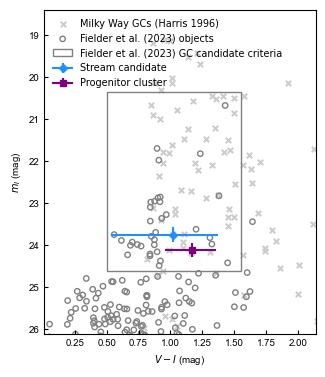

In [19]:
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
})
fsize = 7

# 89 mm width (in inches) with aspect ratio 6/5
fig = plt.figure(figsize=(89/25.4, 89/25.4 * 6.0/5.0))
ax = fig.add_subplot()

ax.set_xlim(0.01, 2.14)
ax.set_ylim(26.1,18.4)

ax.set_xlabel(r'$V-I$ (mag)', fontfamily='Arial', fontsize=7)
ax.set_ylabel(r'$m_I$ (mag)', fontfamily='Arial', fontsize=7)

ax.tick_params(axis='both', labelsize=7, length=3, direction='in')

#ax.errorbar(Fielder_f555w-Fielder_f814w, Fielder_f814w, xerr=np.sqrt(Fielder_f555w_err**2 + Fielder_f814w_err**2), yerr=Fielder_f814w_err, fmt='.',color='k', alpha=0.3, label = 'Fielder et al. (2023) objects (in F555W and F814W)')
#ax.scatter(Fielder_f814w-Fielder_f814w, Fielder_f814w, marker='o', s=15, facecolors='none', edgecolor='k', alpha=1)
ax.scatter(Harris_GCs['(V-I)t'], Harris_GCs['mI'], marker='x', s=15, color='0.8', label = 'Milky Way GCs (Harris 1996)')
ax.scatter(FGC_w_conx, FGC_w_cony, marker='o', s=15, facecolors='none', edgecolor='grey', label = 'Fielder et al. (2023) objects')
ax.scatter(FGC_no_conx, FGC_no_cony, marker='o', s=15, facecolors='none', edgecolor='grey')

box = patches.Rectangle((0.5, 24.61), 1.05, (20.35-24.61), facecolor='none', edgecolor='grey', label = 'Fielder et al. (2023) GC candidate criteria')
ax.add_patch(box)

xerr_stream_upper = np.sqrt(error_corr555_mag_upper**2 + error_corr814_mag_upper**2)
xerr_stream_lower = np.sqrt(error_corr555_mag_lower**2 + error_corr814_mag_lower**2)
xerr_stream = np.array([[xerr_stream_lower, xerr_stream_upper]]).T

xerr_clus_upper = np.sqrt(error_corr_clus555_mag_upper**2 + error_corr_clus814_mag_upper**2)
xerr_clus_lower = np.sqrt(error_corr_clus555_mag_lower**2 + error_corr_clus814_mag_lower**2)
xerr_clus = np.array([[xerr_clus_lower, xerr_clus_upper]]).T

#subtract dust reddening of 0.055 in F555W and 0.031 in F814W, and add 0.05 to the color to go from F555W to V:
ax.errorbar(corr_stream_mag555+0.055+0.05-(corr_stream_mag814+0.031), corr_stream_mag814+0.031, 
            yerr = np.array([[error_corr814_mag_lower, error_corr814_mag_upper]]).T, xerr = xerr_stream, 
            ms=4, marker = 'D',color='dodgerblue', label = 'Stream candidate')
ax.errorbar(corr_clus_mag555+0.055+0.05-(corr_clus_mag814+0.031), corr_clus_mag814+0.031, 
            yerr = np.array([[error_corr814_mag_lower, error_corr814_mag_upper]]).T, xerr = xerr_clus, 
            ms=5, marker = 's', color='purple', label = 'Progenitor cluster')

#ax.errorbar(CFHT_g_i_09, CFHT_i_09, xerr = xerr_09, yerr = np.array([[xerr_i_lower_09, xerr_i_upper_09]]).T, marker='*', color='orange', label = 'CFHT g-i, W131')
#ax.errorbar(CFHT_g_i_12, CFHT_i_12, xerr = xerr_12, yerr = np.array([[xerr_i_lower_12, xerr_i_upper_12]]).T, marker='*', color='red', label = 'CFHT g-i, W232')

leg = ax.legend(loc='upper left', prop={'family':'sans-serif', 'size':7}, frameon=False)

#fig.savefig('../Figures/CMD_formatted_89mm.eps', bbox_inches='tight')
#ax.text(1.25, 26.7, '-- red --->')

In [20]:
print(f'Stream color (V-I): {(corr_stream_mag555+0.055+0.05)-(corr_stream_mag814+0.031):.4f} -{xerr_stream_lower:.4f} +{xerr_stream_upper:.4f} mag')
print(f'Stream magnitude (I): {corr_stream_mag814+0.031:.4f} -{error_corr814_mag_lower:.4f} +{error_corr814_mag_upper:.4f} mag')
print(f'Cluster color (V-I): {(corr_clus_mag555+0.055+0.05)-(corr_clus_mag814+0.031):.4f} -{xerr_clus_lower:.4f} +{xerr_clus_upper:.4f} mag')
print(f'Cluster magnitude (I): {corr_clus_mag814+0.031:.4f} -{error_corr814_mag_lower:.4f} +{error_corr814_mag_upper:.4f} mag')

Stream color (V-I): 1.0211 -0.4893 +0.3557 mag
Stream magnitude (I): 23.7619 -0.1849 +0.1580 mag
Cluster color (V-I): 1.1721 -0.2166 +0.1887 mag
Cluster magnitude (I): 24.1199 -0.1849 +0.1580 mag


#### Transparant for talks

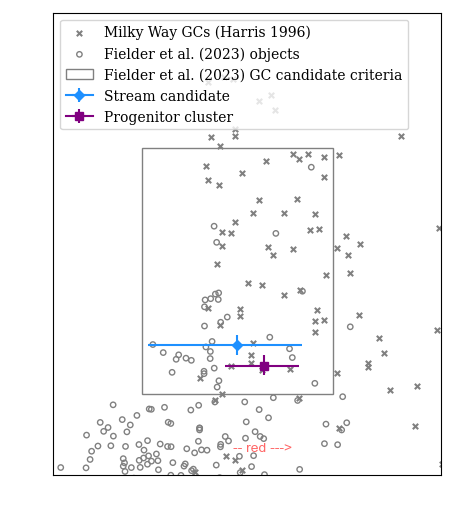

In [21]:
cmdfig_white = plt.figure(figsize=(5, 6))
ax_white = cmdfig_white.add_subplot()

ax_white.set_xlim(0.01, 2.14)
ax_white.set_ylim(26.0, 18.0)
ax_white.set_xlabel('V-I [mag]', font='serif', fontsize=12, color='white')
ax_white.set_ylabel(r'm_I [mag]', font='serif', fontsize=12, color='white')


ax_white.scatter(Harris_GCs['(V-I)t'], Harris_GCs['mI'], marker='x', s=15, color='grey', label='Milky Way GCs (Harris 1996)')
ax_white.scatter(FGC_w_conx, FGC_w_cony, marker='o', s=15, facecolors='none', edgecolor='grey', label='Fielder et al. (2023) objects')
ax_white.scatter(FGC_no_conx, FGC_no_cony, marker='o', s=15, facecolors='none', edgecolor='grey')

box_white = patches.Rectangle((0.5, 24.61), 1.05, (20.35 - 24.61), facecolor='none', edgecolor='grey', label='Fielder et al. (2023) GC candidate criteria')
ax_white.add_patch(box_white)

xerr_stream_upper = np.sqrt(error_corr555_mag_upper**2 + error_corr814_mag_upper**2)
xerr_stream_lower = np.sqrt(error_corr555_mag_lower**2 + error_corr814_mag_lower**2)
xerr_stream = np.array([[xerr_stream_lower, xerr_stream_upper]]).T

xerr_clus_upper = np.sqrt(error_corr_clus555_mag_upper**2 + error_corr_clus814_mag_upper**2)
xerr_clus_lower = np.sqrt(error_corr_clus555_mag_lower**2 + error_corr_clus814_mag_lower**2)
xerr_clus = np.array([[xerr_clus_lower, xerr_clus_upper]]).T

ax_white.errorbar(
    corr_stream_mag555 + 0.055 + 0.05 - (corr_stream_mag814 + 0.031),
    corr_stream_mag814 + 0.031,
    yerr=np.array([[error_corr814_mag_lower, error_corr814_mag_upper]]).T,
    xerr=xerr_stream,
    ms=5,
    marker='D',
    color='dodgerblue',
    label='Stream candidate'
 )
ax_white.errorbar(
    corr_clus_mag555 + 0.055 + 0.05 - (corr_clus_mag814 + 0.031),
    corr_clus_mag814 + 0.031,
    yerr=np.array([[error_corr814_mag_lower, error_corr814_mag_upper]]).T,
    xerr=xerr_clus,
    ms=6,
    marker='s',
    color='purple',
    label='Progenitor cluster'
 )

cmdfig_white.set_facecolor('none')
ax_white.tick_params(axis='both', colors='white')
ax_white.xaxis.label.set_color('white')
ax_white.yaxis.label.set_color('white')
ax_white.text(1., 25.6, '-- red --->', fontsize=10, c='r', alpha=0.6)
legend = ax_white.legend(loc='upper left', prop={'family': 'serif', 'size': 10})

#plt.savefig('../Figures/CMD_trans_layer0.png', dpi=600, bbox_inches='tight', transparent=False)


In [22]:
#setting up phiphi coord system
endpoints = pd.read_csv('../Clicked_points/stream_endpoints.csv').values
ep_wcs = wcs_HST.pixel_to_world(endpoints[:,0], endpoints[:,1])
phiphifr = gc.GreatCircleICRSFrame.from_endpoints(ep_wcs[0], ep_wcs[1])

# Transform image to phiphi coordinate system 
def transform_image(image, frame=phiphifr):
    # Create meshgrid indeces for coordinate calculation
    ny, nx = image.shape
    y, x = np.mgrid[0:ny, 0:nx]
    
    if frame==phiphifr:
        # Crop image to speed up everything later
        crop_im = image[3000:3500, 2200:2800]
        # Need to calculate sky coords for total image to use what's in header, then crop to cropped image size afterwards
        sky_coords = wcs_HST.pixel_to_world(x, y)[3000:3500, 2200:2800]
    elif frame == phiphifr_CFHT: 
        sky_coords = wcs_CFHT.pixel_to_world(x, y)
        crop_im = image
    else:
        print('wrong frame')
        return

    # Transform to phiphi system and get new coord arrays in degrees
    rotated = sky_coords.transform_to(frame)
    phi1 = rotated.phi1.deg
    phi2 = rotated.phi2.deg
    # phi1 and phi2 are now corresponding to coordinates in cropped image

    # Flatten input for interpolation
    points = np.vstack([phi1.ravel(), phi2.ravel()]).T
    values = crop_im.ravel()
    ncy, ncx = crop_im.shape

    # make linear grid corresponding to crop_large
    phi1_lin = np.linspace(np.nanmin(phi1), np.nanmax(phi1), ncx)
    phi2_lin = np.linspace(np.nanmin(phi2), np.nanmax(phi2), ncy)

    # for imshow plotting
    ext = [phi1_lin[0], phi1_lin[-1], phi2_lin[0], phi2_lin[-1]]

    # making a meshgrid
    grid_phi1, grid_phi2 = np.meshgrid(phi1_lin, phi2_lin)

    # Interpolate
    phi_image = griddata(points, values, (grid_phi1, grid_phi2), method='linear', rescale=True)
    # phi_image is now cropped image rotated into the phiphi frame
    return phi_image, ext


In [23]:

def smooth_image(image, type = 'gaussian', param = 2.):
    # make copy and replace NaNs with 0s to avoid edge effects
    im_nonan = image.copy()
    im_nonan[np.isnan(im_nonan)]=0.0

    # smooth the image
    if type == 'gaussian':
        return nd.gaussian_filter(im_nonan, sigma=param, mode='wrap')
    elif type == 'uniform':
        return nd.uniform_filter(im_nonan, size=param, mode='wrap')

In [24]:
phi_image, extent = transform_image(im814)
smooth_phi_im = smooth_image(phi_image,param=3)
extent_arc = (np.array(extent)*u.deg.to(u.arcsec)).astype(list)

# phi1 and phi2 coord arrays
im_phi1 = np.linspace(extent[0], extent[1], len(smooth_phi_im[0]))
im_phi2 = np.linspace(extent[2], extent[3], len(smooth_phi_im))

In [25]:
phi_masks,_ = transform_image(masks, frame=phiphifr)
phi_masks_clus,_ = transform_image(masks_clus, frame=phiphifr)
phi_streammask,_ = transform_image(streammask, frame=phiphifr)
phi_clusmask,_ = transform_image(clusmask, frame=phiphifr)

In [26]:
# Find contours where masks is not nan
mask_bool = ~np.isnan(masks)
contours = measure.find_contours(mask_bool.astype(float), level=0.5)

# Convert the first contour to a polygon path (if multiple, you may want to select the largest)
if contours:
    contour = contours[0]
    polygon_path = Path(contour)
else:
    polygon_path = None

#WCS_poly = wcs_HST.pixel_to_world(polygon_path.vertices)

#plt.plot(polygon_path.vertices[:, 1], polygon_path.vertices[:, 0], 'r-')

In [31]:
s = 2
fsize=7
figsize=89

r_up = 90
r_low = 45
b_up = 90
b_low = 80
g_up = np.mean([r_up, b_up])
g_low = np.mean([r_low, b_low])


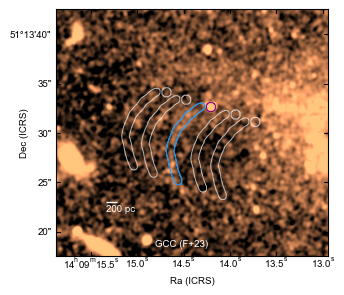

In [ ]:
fig = plt.figure(figsize=(figsize/25.4,figsize/25.4))
ax_im = fig.add_subplot(projection=wcs_HST)
ax_im.set_xlim(2250, 2800)
ax_im.set_ylim(3000, 3500)
ax_im.set_ylabel('Dec (ICRS)', fontsize=fsize, labelpad=-1.5)
ax_im.set_xlabel('Ra (ICRS)',fontsize=fsize)
ax_im.tick_params(axis='both', labelsize=fsize, length=3, direction='in')
ax_im.set_xticks([],[])
ax_im.set_yticks([],[])

#ax_im.imshow(smooth, norm = normcomp, cmap='copper', aspect=1)
ax_im.imshow(nd.gaussian_filter(im814, 3), norm = simple_norm(im814, stretch='asinh', min_percent=r_low, max_percent=r_up, asinh_a=0.3), cmap='copper', aspect=1)

ax_im.contour(np.isnan(masks), levels=np.array([-1,0,1]), linewidths=0.7, cmap='PiYG', alpha=0.7)
ax_im.contour(np.isnan(streammask), levels=np.array([-2,0,1]), linewidths=0.7, cmap='gist_rainbow')
ax_im.contour(np.isnan(masks_clus), levels=np.array([-1,0,1]), linewidths=0.8, cmap='PiYG', alpha=0.7)
ax_im.contour(np.isnan(clusmask), levels=np.array([-5,0,1]), linewidths=0.8, cmap='RdPu')
ax_im.hlines(3110,2350, 2350+1/px_size*200, color='w', linewidth=1)
ax_im.text(2350,3090,'200 pc', color='w',fontsize=fsize)
ax_im.text(2450,3020, 'GCC (F+23)', color='w',fontsize=fsize)

#fig.savefig('../Figures/Backgrounds_F814W_formatted_89mm.eps', bbox_inches='tight')